In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

import ast
        
model_name_dict = {"EGB_XGB_GA2M_CYCLIC_CYCLIC":"EG$^2$B",
                  "EGB_XGB_GA2M_CYCLIC_BEST_FIT":"EG$^2$B-BF$^2$",
                  "EGB_XGB_GA2M_BEST_FIT_BEST_FIT":"EG$^2$B-BF",
                  "EBM_GA2M":"EB$^2$M",
                  "XGB":"XGBoost",
                    "EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE":"EGB-CyclicRev",
                  "EGB_XGB_GAM_CYCLIC_CYCLIC":"EGB",
                  "EGB_XGB_GAM_BEST_FIT_BEST_FIT":"EGB-BF",
                   "EBM_GAM":"EBM",
                  "Spline":"Spline",
                  }
METHODS_LIST=model_name_dict.keys()

def extract_mean(s):
    if isinstance(s, float):
        return s

    if isinstance(s, str):
        if '±' in s:
            s = s[:s.index('±')]
        return float(s)

    raise Exception('the input is wierd: %s' % str(s))
    
def rank(x, is_metric_higher_better=True):
    x = x.apply(extract_mean)
    return x.rank(method='average', ascending=(not is_metric_higher_better), na_option='bottom')

def normalized_score(x, is_metric_higher_better=True, min_value=None):
    x = x.apply(extract_mean)
    if min_value is None:
        min_value = x.min()

    score = (x - min_value) / (x.max() - min_value)
    if not is_metric_higher_better:
        score = 1. - score
    return score

def add_new_row(table, series, row_name):
    new_indexes = list(table.index) + [row_name]
    new_table = table.append(series, ignore_index=True)
    new_table.index = new_indexes
    return new_table

def highlight_min_max(x):
    x = x.apply(extract_mean)
    return ['background-color: #cd4f39' if v == np.nanmax(x) else ('background-color: lightgreen' if v == np.nanmin(x) else '') for v in x]

def cal_statistics(table, metric, is_metric_higher_better):
    # Add two rows
    mean_score = table.apply(lambda x: x.apply(lambda s: float(s[:s.index('±')] if isinstance(s, str) and '±' in s else s)).mean(), axis=0)
    new_table = add_new_row(table, mean_score.apply(lambda x: '%.4f' % x), 'average')
    
    average_rank = mean_score.rank(ascending=(not is_metric_higher_better))
    new_table = add_new_row(new_table, average_rank, 'average_rank')

    mean_rank = table.apply(rank, axis=1, is_metric_higher_better=is_metric_higher_better).mean()
    new_table = add_new_row(new_table, mean_rank.apply(lambda x: '%.2f' % x), 'avg_rank')
    
    avg_rank_rank = mean_rank.rank(ascending=True)
    new_table = add_new_row(new_table, avg_rank_rank, 'avg_rank_rank')

    normalized_score_ = table.apply(normalized_score, axis=1, is_metric_higher_better=is_metric_higher_better)
    #display(normalized_score_)
    mean_normalized_score = normalized_score_.mean()

    new_table = add_new_row(new_table, mean_normalized_score.apply(lambda x: '%.3f' % x), 'avg_score')
    avg_score_rank = mean_normalized_score.rank(ascending=False)
    new_table = add_new_row(new_table, avg_score_rank, 'avg_score_rank')
    
    if 'auc' in metric:
        mean_normalized_score_b = table.apply(normalized_score, axis=1, min_value=0.5, is_metric_higher_better=is_metric_higher_better).mean()
        new_table = add_new_row(new_table, mean_normalized_score_b.apply(lambda x: '%.3f' % x), 'avg_score_b0.5')

        avg_score_rank_b = mean_normalized_score_b.rank(ascending=False)
        new_table = add_new_row(new_table, avg_score_rank_b, 'avg_score_b0.5_rank')

    return new_table

def model_filter(table, par, val, and_=False):

    if1 = table['model_name'].str.contains("%s=%s" %(par, val))
    if2 = ~table['model_name'].str.contains("%s=" % (par))
    if and_:
        return table[if1]
    else:
        return table[if1 | if2]

def print_latex_old(table, datasets, methods=METHODS_LIST):
            
    print("{c |"+" c"*(4)+"|"+" c"*(4)+"|c}")
    print("\hline")
    print('&  \multicolumn{4}{c}{GAM}&\multicolumn{4}{c}{GA$^2$M}&')
    print('\\\ ')
    print("Dataset"+'&')
    print("& ".join([model_name_dict[method] for method in methods]))
    print('\\\ \hline')
        
    for dataset in datasets+["avg_rank", "average"]:
        try:
            row = table.loc[dataset.lower()] 
        except :
            continue
        if dataset=="California housing":
            dataset="Housing"
        if dataset=="avg_rank":
            dataset="Rank"
        if dataset=="avg_score":
            dataset="NS"
        print(dataset+'&')
        #\textbf{bold}
        scores = row.apply(extract_mean)
        if dataset == "Rank":
            max_score_method = scores.min()
        else:
            max_score_method = scores.max()
        max_methods = scores[scores==max_score_method].index.values
        #display(max_methods)
        line = ""
        

        
        for method in METHODS_LIST:
            if method not in row:
                continue
            value = str(row[method])
            value = value.replace("-", "")
            if value[0] == "0":
                value = value[1:]
            value = value.replace("±0.", "±.")
            if method in max_methods:
                value = "\\textbf{%s}" % value
            line+=value
            line+='&'
        print(line[:-1])
        if dataset in ['Student']:
            print('\\\ \hline')
        else:
            print('\\\ ')

def print_latex(table, datasets, methods=METHODS_LIST):


    datasets += ["avg_rank"]
    dic_datasets = {data_set:data_set for data_set in datasets}
    dic_datasets["California housing"] = "Housing"

    dic_datasets["avg_rank"] = "Rank"
    dic_datasets["avg_score"] = "NS"

    print("{c c |"+" c"*(len(datasets))+"}")
    print("\hline")
    #print("Model"+'& \\rotatebox[origin=c]{45\}{')
    #print("\}& \rotatebox[origin=c]{45\}{".join([dic_datasets[dataset] for dataset in datasets]))
    print("& Model"+'& \\')
    print("& ".join([dic_datasets[dataset] for dataset in datasets]))
    print('\\\ \hline')
    display(table.head())
    for method in methods:
        #display(max_methods)
        line = ""
        if model_name_dict[method] == "EGB":
                print("\\multirow{4}{*}{\\rotatebox[origin=c]{90}{GAM}}")
        elif model_name_dict[method] == "EG$^2$B":
                print("\\multirow{4}{*}{\\rotatebox[origin=c]{90}{GA$^2$M}}")
                     
        print('&'+model_name_dict[method]+'&')
        for dataset in datasets:
            try:
                row = table.loc[dataset.lower()] 
            except :
                continue
            #\textbf{bold}
            scores = row.apply(extract_mean)
            if dataset == "avg_rank":
                max_score_method = scores.min()
            else:
                max_score_method = scores.max()
            max_methods = scores[scores==max_score_method].index.values

            if method not in row:
                continue
            value = str(row[method])
            value = value.replace("-", "")
            if value[0] == "0":
                value = value[1:]
            value = value.replace("±0.", "±.")
            if method in max_methods:
                value = "\\textbf{%s}" % value
            line+=value
            line+='&'
        print(line[:-1])
        if model_name_dict[method] in ["EGB-BF", "EG$^2$B-BF"]:
            print('\\\ \hline')
        else:
            print('\\\ ')

def display_metric(results, metric = 'test_score', limit_dig_m = 1, limit_dig_s = 2, 
                   flag_latex=True, split_reg_class=True, latex_datasets_head=True, methods=METHODS_LIST):
    results = results[results["model_name"].isin(methods)]

    datasets_class = ["Adult", "Churn", "COMPAS",  "Support2", 'breast']#
    datasets_reg = ["Bike", "California housing", "Wine",  'crimes', "fico"]#"Concrete",
    datasets_types = ["both"]
    if split_reg_class:
        datasets_types = ["class", "reg"]
    for class_reg in datasets_types:
        #display(class_reg)
        datasets = datasets_reg.copy()
        limit_dig_m = 3
        limit_dig_s = 2

        if class_reg == "both":
            datasets = datasets_class + datasets_reg
            limit_dig_s = 2
        elif class_reg == "class":
            datasets = datasets_class
            limit_dig_m = 3
            limit_dig_s = 2
            
        table = results.copy()

        table['d_name'] = table['d_name'].replace("compass", "compas").str.lower()
        
        table = table[table['d_name'].isin([dataset.lower() for dataset in datasets])]
        
        table = model_filter(table, 'l2', "0,4")

        format_m = lambda x: ('{0:.'+str(limit_dig_m)+'f}').format(x)
        format_s = lambda x: ('{0:.'+str(limit_dig_s)+'f}').format(x)

        if metric+'_std' in table.columns:
            table.loc[:, metric+"_+std"] = table[metric+'_mean'].round(limit_dig_m).apply(format_m)+\
            "±"+table[metric+'_std'].round(limit_dig_m).apply(format_s)
        else:
            table[metric+"_+std"] = table[metric].round(limit_dig_m).apply(format_m)
        #display(table[['d_name', 'model_name', metric+"_+std"]].head())


        table = pd.pivot_table(table[['d_name', 'model_name', metric+"_+std"]], aggfunc=lambda x: ' '.join(x),
                               index='d_name', columns=['model_name'])[metric+"_+std"]#.dropna(axis=1)

        table = cal_statistics(table, '', is_metric_higher_better=True)
        table = table.sort_values(by ='avg_rank', axis=1)
        pd.options.display.float_format = '{:,.3f}'.format
        display(table.style.apply(highlight_min_max, axis=1))
        if flag_latex:
            if  latex_datasets_head:
                print_latex(table, datasets=datasets.copy(), methods=methods)
            else:
                print_latex_old(table, datasets=datasets.copy(), methods=methods)

    return table



accuracy_results = pd.read_csv("../accuracy_results.csv")


accuracy_results_stats = display_metric(accuracy_results, metric = 'test_score', split_reg_class=True, 
                                        latex_datasets_head=True, flag_latex=False, methods=METHODS_LIST)

summarry_accuarcy = accuracy_results_stats.loc["avg_rank", :].reset_index()
summarry_accuarcy.loc[:, "exp"] = "accuracy"
display(summarry_accuarcy)


model_name,EBM_GA2M,EGB_XGB_GAM_BEST_FIT_BEST_FIT,EGB_XGB_GAM_CYCLIC_CYCLIC,XGB,EGB_XGB_GA2M_CYCLIC_CYCLIC,EGB_XGB_GA2M_CYCLIC_BEST_FIT,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,EBM_GAM,Spline,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE
adult,0.931±0.00,0.929±0.00,0.930±0.00,0.931±0.00,nan,nan,nan,0.930±0.00,0.921±0.00,nan
breast,0.993±0.01,0.992±0.01,0.994±0.01,0.994±0.01,0.994±0.01,0.994±0.01,0.992±0.01,0.993±0.01,0.983±0.01,0.994±0.01
churn,0.843±0.01,0.844±0.01,0.843±0.01,0.833±0.01,nan,nan,nan,0.842±0.01,0.845±0.01,nan
compas,0.745±0.01,0.746±0.01,0.744±0.01,0.738±0.01,0.745±0.01,0.745±0.01,0.746±0.01,0.743±0.01,0.745±0.01,nan
support2,0.827±0.01,0.820±0.01,0.818±0.01,0.821±0.01,0.824±0.02,0.823±0.02,0.824±0.02,0.818±0.02,0.817±0.01,nan
average,0.8678,0.8662,0.8658,0.8634,0.8543,0.8540,0.8540,0.8652,0.8622,0.9940
average_rank,2.000000,3.000000,4.000000,6.000000,8.000000,9.500000,9.500000,5.000000,7.000000,1.000000
avg_rank,3.40,4.60,4.90,4.90,5.40,5.70,5.90,6.10,6.10,8.00
avg_rank_rank,1.000000,2.000000,3.500000,3.500000,5.000000,6.000000,7.000000,8.500000,8.500000,10.000000
avg_score,0.923,0.767,0.717,0.480,0.858,0.825,0.839,0.657,0.375,1.000


model_name,XGB,EGB_XGB_GAM_BEST_FIT_BEST_FIT,EBM_GA2M,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,EGB_XGB_GA2M_CYCLIC_BEST_FIT,EGB_XGB_GA2M_CYCLIC_CYCLIC,EGB_XGB_GAM_CYCLIC_CYCLIC,EBM_GAM,Spline,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE
bike,-39.389±1.87,-97.506±1.22,-50.763±1.36,nan,nan,nan,-97.557±1.21,-97.627±1.17,-97.617±1.26,nan
california housing,-0.465±0.01,-0.567±0.01,-0.504±0.01,-0.493±0.01,-0.496±0.01,-0.500±0.01,-0.571±0.01,-0.568±0.01,-0.599±0.01,nan
crimes,-0.140±0.00,-0.134±0.01,-0.137±0.01,-0.134±0.01,-0.135±0.01,-0.136±0.01,-0.136±0.01,-0.137±0.01,-0.145±0.00,-0.136±0.01
fico,-3.219±0.05,-3.500±0.10,-3.250±0.08,-3.245±0.10,-3.241±0.06,-3.240±0.08,-3.511±0.09,-3.512±0.09,-3.509±0.09,nan
wine,-0.652±0.01,-0.711±0.01,-0.690±0.01,nan,nan,nan,-0.709±0.01,-0.712±0.01,-0.744±0.03,nan
average,-8.7730,-20.4836,-11.0688,-1.2907,-1.2907,-1.2920,-20.4968,-20.5112,-20.5228,-0.1360
average_rank,5.000000,7.000000,6.000000,2.500000,2.500000,4.000000,8.000000,9.000000,10.000000,1.000000
avg_rank,2.60,4.10,4.30,4.90,5.20,5.60,5.60,6.90,7.40,8.40
avg_rank_rank,1.000000,2.000000,3.000000,4.000000,5.000000,6.500000,6.500000,8.000000,9.000000,10.000000
avg_score,0.891,0.328,0.744,0.901,0.868,0.828,0.282,0.261,0.002,0.818


,model_name,avg_rank,exp
0,XGB,2.60,accuracy
1,EGB_XGB_GAM_BEST_FIT_BEST_FIT,4.10,accuracy
2,EBM_GA2M,4.30,accuracy
3,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,4.90,accuracy
4,EGB_XGB_GA2M_CYCLIC_BEST_FIT,5.20,accuracy
5,EGB_XGB_GA2M_CYCLIC_CYCLIC,5.60,accuracy
6,EGB_XGB_GAM_CYCLIC_CYCLIC,5.60,accuracy
7,EBM_GAM,6.90,accuracy
8,Spline,7.40,accuracy
9,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE,8.40,accuracy


In [6]:
METHODS_LIST_times=[
    'EGB_XGB_GAM_CYCLIC_CYCLIC',
    'EBM_GAM',
    'Spline',
    'EGB_XGB_GA2M_CYCLIC_CYCLIC',
    'EBM_GA2M',
    'XGB'
    ]
accuracy_results['fit_time_mean'] = -1*accuracy_results['fit_time_mean']
accuracy_results_stats = display_metric(accuracy_results, metric = 'fit_time_mean', split_reg_class=False, 
                                        latex_datasets_head=False, flag_latex=False, methods=METHODS_LIST_times)

model_name,EBM_GA2M,Spline,EBM_GAM,XGB,EGB_XGB_GA2M_CYCLIC_CYCLIC
adult,48.474,47.060,39.320,0.554,nan
bike,170.401,9.319,14.809,1.127,nan
breast,5.998,202.841,1.987,0.063,60.060
california housing,147.442,10.684,25.884,0.856,nan
churn,3.345,4.155,1.942,0.106,nan
compas,2.256,1.835,1.525,0.071,nan
crimes,7.999,556.342,1.571,0.203,139.256
fico,13.813,22.030,8.359,0.237,nan
support2,7.617,74.560,3.217,0.174,nan
wine,14.685,5.101,1.652,0.275,nan


model_name,EBM_GA2M,EGB_XGB_GA2M_CYCLIC_BEST_FIT,EGB_XGB_GA2M_CYCLIC_CYCLIC,EBM_GAM,EGB_XGB_GAM_CYCLIC_CYCLIC,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,EGB_XGB_GAM_BEST_FIT_BEST_FIT,Spline,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE
adult,0.348,0.336,0.336,0.337,0.331,nan,0.324,nan,nan
bike,0.416,0.417,0.407,0.241,0.240,nan,0.241,0.314,nan
breast,0.376,0.425,0.425,0.369,0.421,0.313,0.316,nan,0.420
california housing,0.531,0.498,0.509,0.429,0.427,0.505,0.422,0.860,nan
churn,0.315,0.310,0.310,0.307,0.311,nan,0.257,0.252,nan
compas,0.426,0.430,0.427,0.408,0.409,0.427,0.416,0.349,nan
crimes,0.585,0.592,0.590,0.577,0.575,0.244,0.244,nan,0.575
fico,0.266,0.264,0.264,0.237,0.237,0.222,0.196,nan,nan
support2,0.322,0.289,0.290,0.252,0.240,0.287,0.237,nan,nan
wine,0.366,0.350,0.357,0.255,0.256,nan,0.220,0.226,nan


,model_name,avg_rank,exp
0,XGB,2.60,accuracy
1,EGB_XGB_GAM_BEST_FIT_BEST_FIT,4.10,accuracy
2,EBM_GA2M,4.30,accuracy
3,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,4.90,accuracy
4,EGB_XGB_GA2M_CYCLIC_BEST_FIT,5.20,accuracy
5,EGB_XGB_GA2M_CYCLIC_CYCLIC,5.60,accuracy
6,EGB_XGB_GAM_CYCLIC_CYCLIC,5.60,accuracy
7,EBM_GAM,6.90,accuracy
8,Spline,7.40,accuracy
9,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE,8.40,accuracy


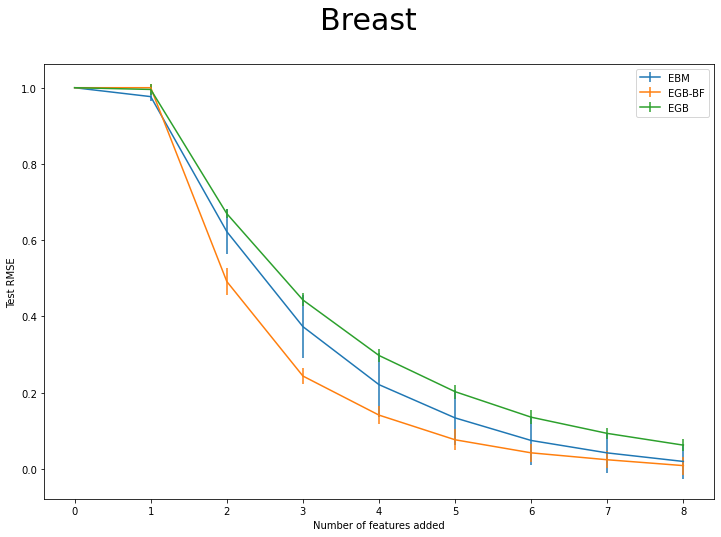

In [2]:
feature_sparsness_results = pd.read_csv("../feature_sparseness_results.csv")

feature_sparsness_results_stats = display_metric(feature_sparsness_results, metric = 'area_till_zero_mean'
                                                , split_reg_class=False, latex_datasets_head=False,
                                                 flag_latex=False, methods=METHODS_LIST)

summarry_stats_sparss = feature_sparsness_results_stats.loc["avg_rank", :].reset_index()
summarry_stats_sparss.loc[:, "exp"] = "feature_sparsness"
summarry_sparss = pd.concat([summarry_accuarcy, summarry_stats_sparss])
display(summarry_sparss)


df = feature_sparsness_results[feature_sparsness_results["d_name"]=="breast"]
#df = df[df["model_name"].isin(METHODS_LIST)]
df = df[df["model_name"].isin(["EBM_GAM",  "EGB_XGB_GAM_CYCLIC_CYCLIC",  "EGB_XGB_GAM_BEST_FIT_BEST_FIT"])]

df.mean_perf = df.mean_perf.apply(ast.literal_eval)
df.std_perf = df.std_perf.apply(ast.literal_eval)

#display(df)
fig, ax = plt.subplots(figsize=(12, 8))
names_current = []
for i, results in df.iterrows():
    
    name  =  model_name_dict[results["model_name"]]
    dataset_name = results["d_name"]
    names_current += [name]
    the_mean = np.array(results["mean_perf"]).astype(float)
    the_std = results["std_perf"]
    #print(the_mean)
    #the_mean, the_std = monotonic_constrain(the_mean, the_std)      
    #print("%s num features %d error %.3f" % (name, len(the_mean), np.mean(results["error"])))
    ax.errorbar(range(len(the_mean)), the_mean, the_std, label=name)
    #ax.set_ylim(-0.05, 1.05)
ax.legend(names_current)
interactions = 16
fig.suptitle(dataset_name.capitalize(), fontsize=30)#  + (" - GA^2M" if interactions>0  else " - GAM"))
ax.set_xlabel('Number of features added')
ax.set_ylabel('Test RMSE')
plt.show()

model_name,XGB,EBM_GA2M,EGB_XGB_GA2M_CYCLIC_CYCLIC,EGB_XGB_GA2M_CYCLIC_BEST_FIT,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,EGB_XGB_GAM_BEST_FIT_BEST_FIT,EGB_XGB_GAM_CYCLIC_CYCLIC,Spline,EBM_GAM
adult,-0.087±0.00,-0.088±0.00,-0.088±0.00,-0.088±0.00,nan,-0.090±0.00,-0.089±0.00,-0.094±0.00,-0.089±0.00
bike,-1560.683±131.45,-2599.380±111.97,-2600.933±112.42,-2607.979±105.18,nan,-9548.828±235.89,-9548.479±239.69,-9547.982±250.16,-9549.036±243.23
breast,-0.038±0.01,-0.038±0.01,-0.037±0.01,-0.037±0.01,-0.037±0.02,-0.037±0.02,-0.036±0.01,-0.097±0.01,-0.041±0.02
california housing,-0.215±0.01,-0.259±0.01,-0.250±0.01,-0.245±0.01,-0.244±0.01,-0.326±0.01,-0.330±0.01,-0.358±0.01,-0.328±0.01
churn,-0.138±0.01,-0.136±0.01,-0.136±0.01,-0.136±0.01,nan,-0.136±0.01,-0.136±0.01,-0.135±0.01,-0.136±0.01
compas,-0.207±0.00,-0.204±0.00,-0.204±0.00,-0.204±0.00,-0.204±0.00,-0.204±0.00,-0.204±0.00,-0.204±0.00,-0.205±0.00
crimes,-0.019±0.00,-0.018±0.00,-0.019±0.00,-0.019±0.00,-0.018±0.00,-0.018±0.00,-0.019±0.00,-0.022±0.00,-0.019±0.00
fico,-10.209±0.38,-10.589±0.51,-10.607±0.46,-10.649±0.46,-10.503±0.57,-12.412±0.72,-12.475±0.67,-12.430±0.63,-12.515±0.66
support2,-0.139±0.01,-0.140±0.01,-0.141±0.01,-0.141±0.01,-0.140±0.01,-0.141±0.01,-0.143±0.01,-0.142±0.01,-0.143±0.01
wine,-0.446±0.01,-0.484±0.01,-0.483±0.01,-0.484±0.01,nan,-0.517±0.02,-0.514±0.02,-0.558±0.06,-0.516±0.02


avg_rank                        
exp                            accuracy  bias feature_sparsness
model_name                                                     
EBM_GA2M                           4.10  3.60              2.00
EBM_GAM                            6.70  7.05              4.90
EGB_XGB_GA2M_BEST_FIT_BEST_FIT     4.70  5.20              6.15
EGB_XGB_GA2M_CYCLIC_BEST_FIT       5.00  4.15              2.50
EGB_XGB_GA2M_CYCLIC_CYCLIC         5.30  3.90              2.55
EGB_XGB_GAM_BEST_FIT_BEST_FIT      4.10  5.20              6.40
EGB_XGB_GAM_CYCLIC_CYCLIC          5.50  5.65              4.95
Spline                             7.20  6.70              6.55
XGB                                2.40  3.55               NaN

model_name,EGB_XGB_GAM_BEST_FIT_BEST_FIT,EBM_GAM,EGB_XGB_GAM_CYCLIC_CYCLIC,Spline,EBM_GA2M,EGB_XGB_GA2M_CYCLIC_CYCLIC,EGB_XGB_GA2M_CYCLIC_BEST_FIT,EGB_XGB_GA2M_BEST_FIT_BEST_FIT,XGB
adult,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,nan,-0.003±0.00
bike,-66.644±5.84,-77.938±5.63,-81.313±4.24,-60.572±4.78,-145.895±8.97,-166.577±14.38,-179.613±15.89,nan,-268.593±10.70
breast,-0.002±0.00,-0.004±0.00,-0.002±0.00,-0.001±0.00,-0.007±0.00,-0.001±0.00,-0.001±0.00,-0.002±0.00,-0.009±0.00
california housing,-0.006±0.00,-0.008±0.00,-0.008±0.00,-0.007±0.01,-0.016±0.00,-0.020±0.00,-0.019±0.00,-0.020±0.00,-0.026±0.00
churn,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,nan,-0.006±0.00
compas,-0.000±0.00,-0.000±0.00,-0.000±0.00,-0.000±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.005±0.00
crimes,-0.000±0.00,-0.000±0.00,-0.000±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.000±0.00,-0.003±0.00
fico,-0.240±0.03,-0.314±0.03,-0.332±0.03,-0.566±0.54,-0.389±0.03,-0.425±0.03,-0.430±0.02,-0.342±0.02,-1.086±0.06
support2,-0.001±0.00,-0.001±0.00,-0.001±0.00,-0.003±0.00,-0.002±0.00,-0.002±0.00,-0.002±0.00,-0.002±0.00,-0.007±0.00
wine,-0.009±0.00,-0.009±0.00,-0.010±0.00,-0.066±0.09,-0.015±0.00,-0.017±0.00,-0.017±0.00,nan,-0.050±0.01


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([2., 3., 4., 5., 6., 7., 8., 9.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

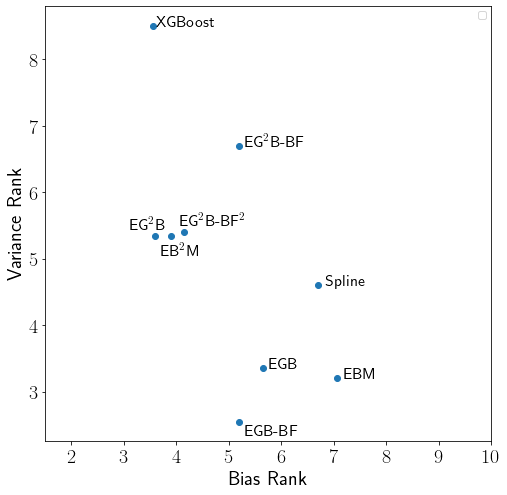

In [3]:
import matplotlib.cm as cm
#!pip install latex

bias_variance_results = pd.read_csv("../bias_variance_results.csv")


bias_variance_results.loc[:, "bias_mean"] = -1*bias_variance_results["bias_mean"]
bias_variance_results.loc[:, "variance_mean"] = -1*bias_variance_results["variance_mean"]

bias_results_stats = display_metric(bias_variance_results, metric = 'bias', flag_latex=False,
                                    split_reg_class=False, methods=METHODS_LIST)

summarry_stats_bias = bias_results_stats.loc["avg_rank", :].reset_index()
summarry_stats_bias.loc[:, "exp"] = "bias"
summarry = pd.concat([summarry_accuarcy, summarry_stats_sparss, summarry_stats_bias])
display(summarry.set_index(["model_name", "exp"]).unstack())

variance_results_stats = display_metric(bias_variance_results, metric = 'variance', flag_latex=False,
                                        split_reg_class=False)
plt.rcParams['text.usetex'] = True

fig, ax = plt.subplots(figsize=(8, 8))
x, y, model_names = bias_results_stats.loc["avg_rank"].sort_index().values.astype(float), \
    variance_results_stats.loc["avg_rank"].sort_index().values.astype(float), bias_results_stats.loc["avg_rank"].sort_index().index
colors = cm.rainbow(np.linspace(0, 1, len(x)))

ax.scatter(x, y)

for i, txt in enumerate(model_names):
    if txt in model_name_dict:
        txt = model_name_dict[txt]
    add_y = 0
    add_x = 0.02
    if txt in ["EGB-BF"]:
        add_y = -0.2
    if txt in ["EB$^2$M"]:
        add_x = 0.03
        add_y = -0.1
    if txt in ["EG$^2$B-BF$^2$"]:
        add_y = 0.1
        add_x = -0.02
    if txt == "EG$^2$B":
        add_y = 0.1
        add_x = -0.2
    if txt == "EB$^2$M":
        add_y = -0.3
        
    ax.annotate(txt, (x[i] + add_x * x[i], y[i]+add_y), size=16)

#plt.xlim(2, 8)
plt.xlim(1.5, 10)

plt.legend()
plt.xlabel('Bias Rank', fontsize=20)
plt.ylabel('Variance Rank', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)